# Install Triton and verify installation

In [1]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [2]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [3]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# SiLU

$$\mathrm{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

### Kernel and Wrapper

In [4]:
@triton.jit
def silu_kernel(
    z_ptr,
    a_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr,
):
    # 1D program id
    pid = tl.program_id(axis=0)
    
    # Compute start position and offset
    block_start = pid * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)

    # Mask for out-of-bound
    mask = offsets < n_elements

    # Load input
    z = tl.load(z_ptr + offsets, mask=mask, other=0.0)

    # Apply SiLU
    a = z * tl.sigmoid(z)

    # Store output
    tl.store(a_ptr + offsets, value=a, mask=mask)
    

def silu(z):
    # Input dimens
    n_rows, n_cols = z.shape
    
    # Allocate output
    a = torch.empty_like(z)

    # Define launch grid
    n_elements = z.numel()
    grid = lambda meta: (triton.cdiv(n_elements, meta["BLOCK_SIZE"]),)

    # Call kernel
    silu_kernel[grid](z, a, n_elements, BLOCK_SIZE=1024)

    return a

### Test and Benchmark Helpers

In [5]:
def test_silu_kernel(size: tuple, atol=1e-6, rtol=1e-5, device=DEVICE):
    # Set random seed
    torch.manual_seed(42)

    assert isinstance(size, tuple) and len(size) == 2
    
    # Create test data
    m, n = size
    z = torch.randn(m, n, device=device)

    # Run triton kernel and PyTorch equivalent
    a_triton = silu(z)
    a_ref = torch.nn.functional.silu(z)

    # Compare
    torch.testing.assert_close(a_triton, a_ref, atol=atol, rtol=rtol)
    print("Passed")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"], # x-axis for plot
        x_vals=[128 * i for i in range(1, 100)], # Different possible values for x_name
        x_log=True, # Log scale for x-axis,
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"], # Label names for the lines
        styles=[("blue", '-'), ("red", '-')], # Line styles
        ylabel="GB/sec", # Label name for y-axis
        plot_name="relu-performance",
        args={'M': 4096}, # Values for function argument not in x_names and y_name
    )
)
def benchmark(M, N, provider):
    # Create input data
    z = torch.randn(M, N, device=DEVICE, dtype=torch.float32)
    quantiles = [0.15, 0.5, 0.85]
    if provider == "torch":
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: torch.nn.functional.silu(z), quantiles=quantiles)
    if provider == "triton":
        # Call wrapper
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: silu(z), quantiles=quantiles)
    
    gbps = lambda ms: 2 * z.numel() * z.element_size() * 1e-9 / (ms * 1e-3) # 2 is used because 1 read and 1 write

    return gbps(min_ms), gbps(ms), gbps(max_ms)

## Test

In [6]:
test_silu_kernel((1025, 4100))
test_silu_kernel((2048, 4096))

Passed
Passed


## Benchmark

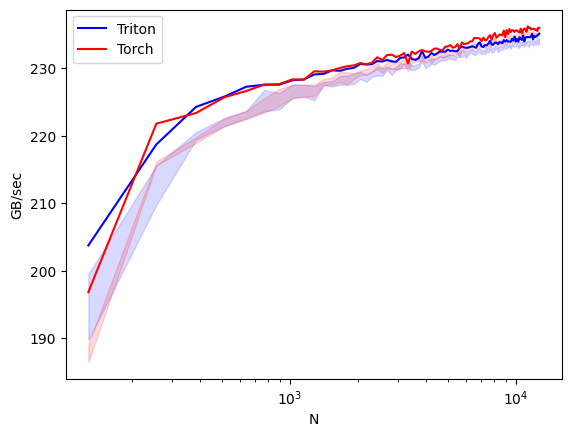

relu-performance:
          N      Triton       Torch
0     128.0  203.749414  196.834358
1     256.0  218.708485  221.780027
2     384.0  224.271949  223.367419
3     512.0  225.791560  225.694361
4     640.0  227.251758  226.623104
5     768.0  227.555555  227.555555
6     896.0  227.555557  227.637414
7    1024.0  228.211769  228.348430
8    1152.0  228.337375  228.293195
9    1280.0  229.068769  229.536095
10   1408.0  229.152318  229.480567
11   1536.0  229.682243  229.682243
12   1664.0  229.610028  230.023827
13   1792.0  229.910535  230.297198
14   1920.0  230.058498  230.417103
15   2048.0  230.623536  230.760556
16   2176.0  230.544482  230.569536
17   2304.0  230.586908  230.814744
18   2432.0  231.060316  231.619049
19   2560.0  230.976096  231.198124
20   2688.0  231.225801  231.935018
21   2816.0  231.011065  232.006375
22   2944.0  230.939108  231.659613
23   3072.0  231.524843  231.849058
24   3200.0  231.598891  232.243986
25   3328.0  232.017428  230.698081
26   3456.

In [7]:
benchmark.run(print_data=True, show_plots=True)